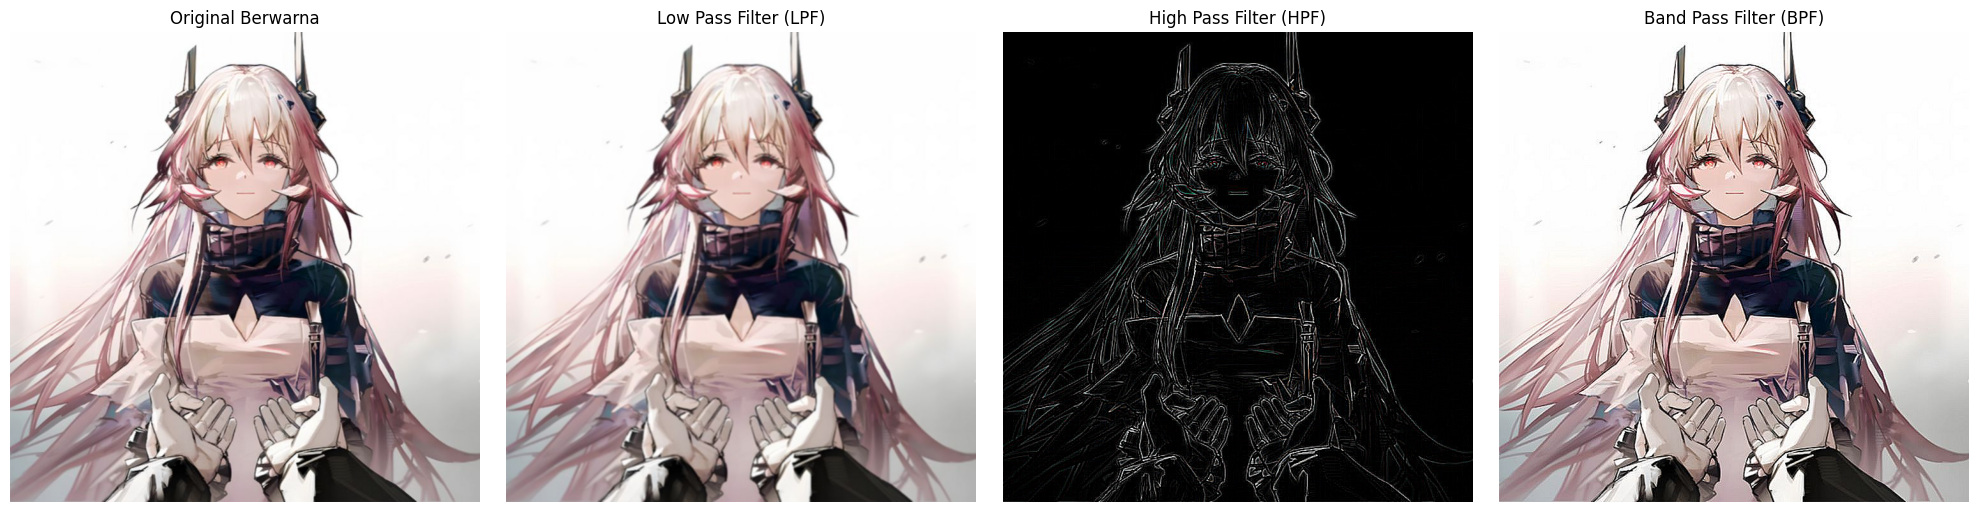

Rata-rata piksel Original : 189.20354036212194
Rata-rata piksel LPF      : 189.2031914579395
Rata-rata piksel HPF      : 11.146891737555135
Rata-rata piksel BPF      : 188.7974995815611


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Baca citra berwarna (tanpa parameter IMREAD_GRAYSCALE)
img_bgr = cv2.imread('Image.jpg')

if img_bgr is not None:
    # Konversi BGR ke RGB agar warnanya sesuai saat ditampilkan di Matplotlib
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Definisi Kernel berdasarkan tabel pada soal
    kernel_lpf = np.ones((3, 3), np.float32) / 9
    kernel_hpf = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]], np.float32)
    kernel_bpf = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], np.float32)

    # 2. Terapkan ketiga kernel (filter2D otomatis bekerja pada 3 channel warna)
    img_lpf = cv2.filter2D(img_rgb, -1, kernel_lpf)
    img_hpf = cv2.filter2D(img_rgb, -1, kernel_hpf)
    img_bpf = cv2.filter2D(img_rgb, -1, kernel_bpf)

    # 3. Tampilkan hasil dalam satu figure
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))

    # Tampilkan gambar tanpa parameter cmap='gray'
    axs[0].imshow(img_rgb)
    axs[0].set_title('Original Berwarna')

    axs[1].imshow(img_lpf)
    axs[1].set_title('Low Pass Filter (LPF)')

    axs[2].imshow(img_hpf)
    axs[2].set_title('High Pass Filter (HPF)')

    axs[3].imshow(img_bpf)
    axs[3].set_title('Band Pass Filter (BPF)')

    for ax in axs:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    # Cetak nilai rata-rata piksel untuk membantu analisa
    print("Rata-rata piksel Original :", np.mean(img_rgb))
    print("Rata-rata piksel LPF      :", np.mean(img_lpf))
    print("Rata-rata piksel HPF      :", np.mean(img_hpf))
    print("Rata-rata piksel BPF      :", np.mean(img_bpf))
else:
    print("Gambar tidak ditemukan.")